In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression

def load_v_ca(npz_path, record_target):
    data = np.load(npz_path, allow_pickle=True)

    variables = data["variables"]

    if record_target == "calcium_acum":
        Ca = variables[0]
        V  = variables[1]

    elif record_target == "potential":
        V  = variables[0]
        Ca = variables[1]

    else:
        raise ValueError(record_target)

    t = data["t_rec"]

    return t, V, Ca


def lagged_mutual_information(
    V,
    Ca,
    max_lag_ms,
    dt_ms
):
    """
    V  : (T, Ncomp)
    Ca : (T, Ncomp)
    """

    max_lag_step = int(max_lag_ms / dt_ms)

    n_comp = V.shape[1]

    lag_axis = np.arange(max_lag_step + 1) * dt_ms

    mi_map = np.zeros((n_comp, len(lag_axis)))


    from tqdm.auto import tqdm

    for comp in tqdm(range(n_comp), desc="Compartment"):
        for lag in range(max_lag_step + 1):
    
            x = V[:-lag or None, comp]
            y = Ca[lag:, comp]
    
            mi = mutual_info_regression(
                x.reshape(-1,1),
                y,
                random_state=0
            )[0]
    
            mi_map[comp, lag] = mi
    
    return lag_axis, mi_map


# ===========================================
# Example
# ===========================================
OUTPUT_PATH = '/home/satoshi/NeuMoReservoir/outputs/2026-06-17/12-01-04/'
t, V, Ca = load_v_ca(
    OUTPUT_PATH + "data/buffer00.npz",
    record_target="calcium_acum"
)

print(f'debug: loaded data')
dt = t[1] - t[0]

lag_axis, mi_map = lagged_mutual_information(
    V,
    Ca,
    max_lag_ms=100,
    dt_ms=dt
)

peak_lag = lag_axis[np.argmax(mi_map, axis=1)]
peak_mi  = np.max(mi_map, axis=1)

print("Peak lag [ms]")
print(peak_lag)

print("Peak MI")
print(peak_mi)

debug: loaded data


Compartment:   0%|          | 0/100 [00:00<?, ?it/s]

Peak lag [ms]
[ 1.625 82.9   96.125  1.5   29.425 85.1    1.95   1.6   83.15   1.575
  1.65   1.825  1.675  0.6    1.425  1.675  1.7   99.     1.55   1.75
  1.725 30.3   96.475  1.625  1.775  1.675  1.575 72.2    1.725  1.7
  1.475  1.775  1.625  1.425  1.6   80.7    1.475  1.725  1.85   2.
  1.8    1.575 30.15   1.7    1.725  1.575  1.75   1.525  1.625  1.75
  1.475  1.325  1.75   1.425  2.05   1.95   1.325  1.65   1.6    1.75
  1.55   1.675  1.7    1.55   1.625  1.65   1.575  1.9    1.525  1.775
  1.275  1.7    1.85   1.7    1.9    1.5   68.575  1.4    1.5    1.6
 76.025  1.625  1.625  1.575  1.65   1.925  1.925 96.825  1.5   92.275
  1.375  1.35  90.35  96.05   1.7    1.425  1.625  1.675  2.05  76.1  ]
Peak MI
[2.78214818 2.27633471 2.06459623 2.85038596 2.5707301  2.21614467
 2.75262792 2.30439846 2.23951357 2.90106975 2.80933987 2.86573515
 2.87487044 2.66686669 2.31488582 2.22454397 2.79482863 2.22532546
 2.76911653 2.68074545 2.77306679 2.53149756 2.16979744 2.66253897
 2.767767

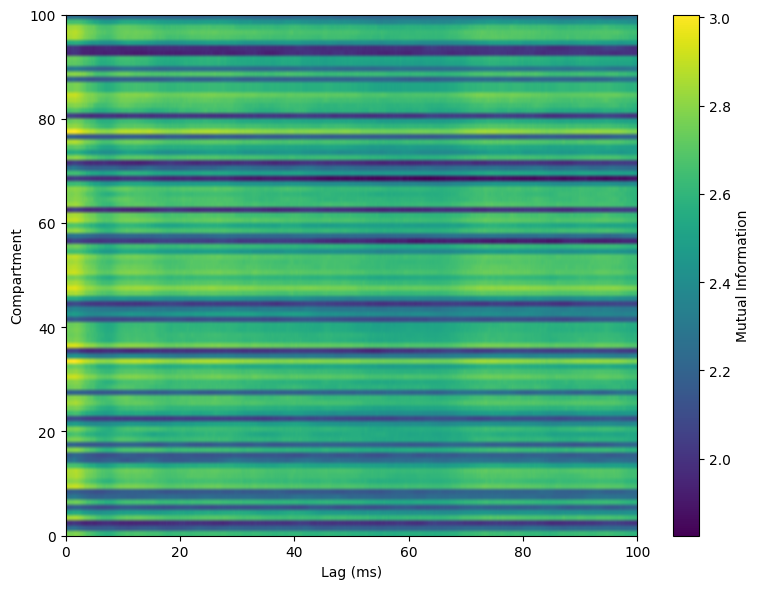

In [2]:
plt.figure(figsize=(8,6))

plt.imshow(
    mi_map,
    aspect="auto",
    origin="lower",
    extent=[
        lag_axis[0],
        lag_axis[-1],
        0,
        mi_map.shape[0]
    ]
)

plt.xlabel("Lag (ms)")
plt.ylabel("Compartment")
plt.colorbar(label="Mutual Information")

plt.tight_layout()
plt.show()

In [3]:
plt.savefig('output.png')

<Figure size 640x480 with 0 Axes>

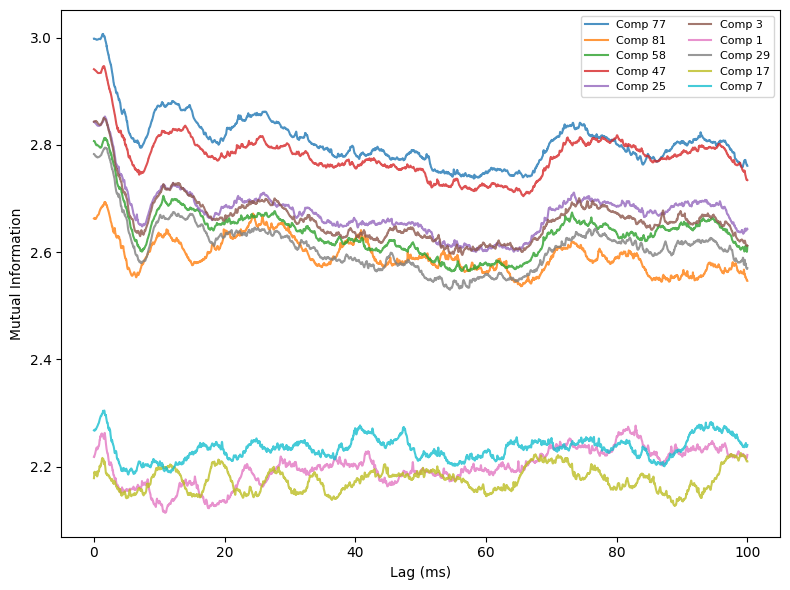

In [4]:
plt.figure(figsize=(8,6))

rng = np.random.default_rng(0)

sampled_compartments = rng.choice(
    mi_map.shape[0],
    size=min(10, mi_map.shape[0]),
    replace=False
)

for comp in sampled_compartments:
    plt.plot(
        lag_axis,
        mi_map[comp],
        alpha=0.8,
        label=f"Comp {comp}"
    )

plt.xlabel("Lag (ms)")
plt.ylabel("Mutual Information")
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()